In [256]:
%run ../../../setup_workspace.py
pi = np.pi

# **Functions**

In [257]:
import plotly.graph_objects as go

def plot_curves(*args, labels=None):
    if len(args) % 2 != 0:
        raise ValueError("Аргументы должны быть парами (x1, y1, x2, y2, ...)")
    
    n_curves = len(args) // 2
    
    if labels is None:
        labels = [f'Кривая {i+1}' for i in range(n_curves)]
    
    fig = go.Figure()
    
    for i in range(n_curves):
        x = args[2*i]
        y = args[2*i + 1]
        
        if isinstance(x, range):
            x = list(x)
        if isinstance(y, range):
            y = list(y)
        
        fig.add_trace(go.Scatter(
            x=x,
            y=y,
            mode='lines+markers',  # линии и маркеры
            name=labels[i]
        ))
    
    fig.update_layout(
        template='none',
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    fig.show()

# **Data**

In [4]:
path = r"E:\OH_PDMS\SC5544\POX_HEMA_100perc_Uncrossl_WithCover"
Exp_heat_1 = BM26_experiment(path)
T_heat_1 = Exp_heat_1.get_T_profile()
Tr_heat_1 = Exp_heat_1.get_Tr_profile()

path = r"E:\OH_PDMS\SC5544\POX_HEMA_100perc_Uncrossl_WithCover_Cool"
Exp_cool_1 = BM26_experiment(path)
T_cool_1 = Exp_cool_1.get_T_profile()
Tr_cool_1 = Exp_cool_1.get_Tr_profile()

path = r"E:\OH_PDMS\SC5544\POX_HEMA_100perc_Uncrossl_WithCover_Heatbis"
Exp_heat_2 = BM26_experiment(path)
T_heat_2 = Exp_heat_2.get_T_profile()
Tr_heat_2 = Exp_heat_2.get_Tr_profile()

path = r"E:\OH_PDMS\SC5544\OH_PDMS_10perc_Uncrossl_after_5hrs_RT"
Exp_aft_5hrs = BM26_experiment(path)
T_aft_5hrs = Exp_aft_5hrs.get_T_profile()
Tr_aft_5hrs = Exp_aft_5hrs.get_Tr_profile()


Found 258 EDF files in SAXS
Found 19 EDF files in SAXS
Found 58 EDF files in SAXS
Found 3 EDF files in SAXS


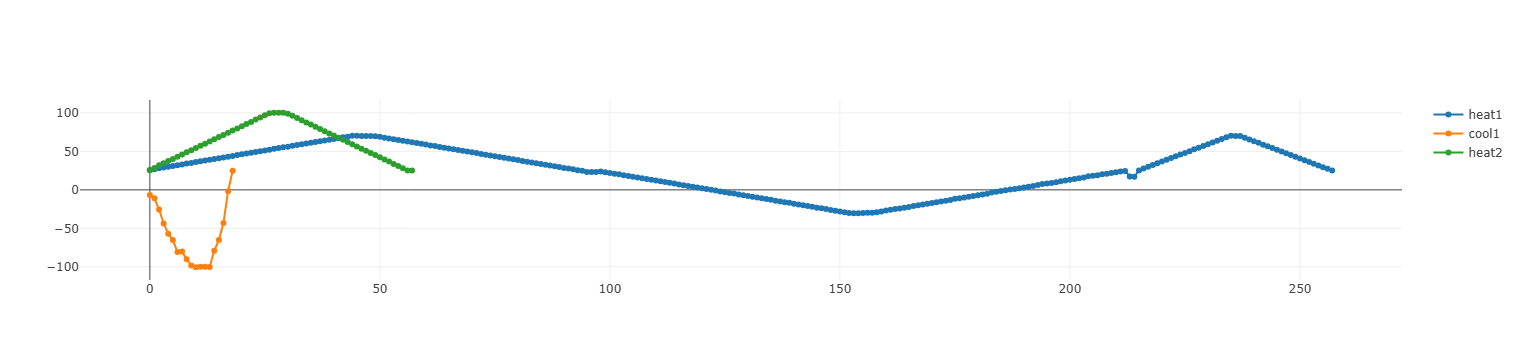

In [5]:
plot_curves(np.arange(258), T_heat_1, np.arange(19), T_cool_1, np.arange(58), T_heat_2,
            labels=['heat1', 'cool1', 'heat2'])

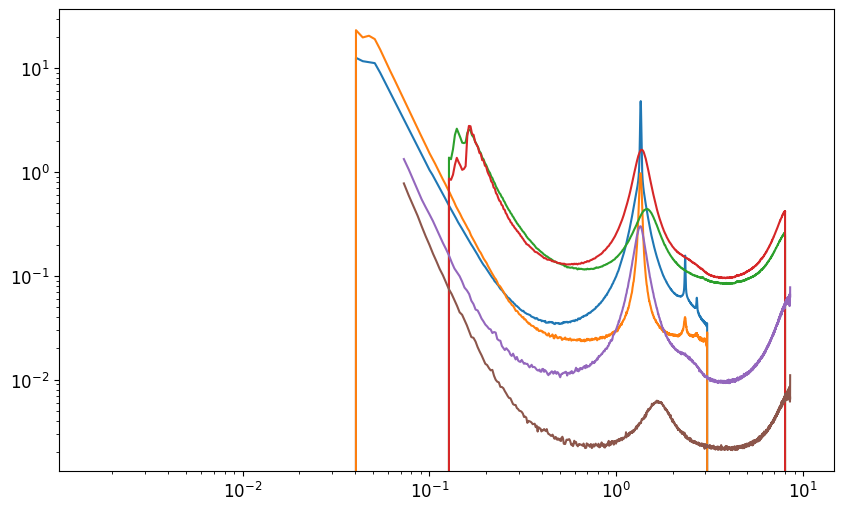

In [198]:
q, I = Exp_aft_5hrs.average_1d([0,1,2])
plt.plot(q, I)
df = pd.DataFrame({'q_100_aft_5hrs':q, 'I_100_aft_5hrs':I})
df.to_csv(r'E:\OH_PDMS\data\NOH100_melt_aft_5hrs.txt', sep=str('\t'), index=False)

path = r"E:\OH_PDMS\SC5544\POX_HEMA_100perc_Uncrossl_WithCover_Heatbis"
Exp_heat_2 = BM26_experiment(path)
q, I = Exp_heat_2.average_1d([0,1,2,3])
plt.loglog(q, I)
df = pd.DataFrame({'q_100':q, 'I_100':I})
df.to_csv(r'E:\OH_PDMS\data\NOH100_melt.txt', sep=str('\t'), index=False)

path = r"E:\sessions\IHSC_1872\NOH_50perc_melt\NOH_50perc_melt_static_1_4m"
Exp = BM26_experiment(path)
q, I = Exp.average_1d([0,1,2,3])
plt.loglog(q, I)
df = pd.DataFrame({'q_50':q, 'I_50':I})
df.to_csv(r'E:\OH_PDMS\data\NOH50_melt.txt', sep=str('\t'), index=False)

path = r"E:\sessions\IHSC_1872\NOH_80perc_melt\NOH_80perc_melt_static_1_4m"
Exp = BM26_experiment(path)
q, I = Exp.average_1d([0,1,2,3])
plt.loglog(q, I)
df = pd.DataFrame({'q_80':q, 'I_80':I})
df.to_csv(r'E:\OH_PDMS\data\NOH80_melt.txt', sep=str('\t'), index=False)

path = r"\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00189_00_norm.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data(0)
plt.loglog(q, I)
df = pd.DataFrame({'q_90':q, 'I_90':I})
df.to_csv(r'E:\OH_PDMS\data\NOH90_melt.txt', sep=str('\t'), index=False)

path = r"\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00245_00_norm.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data(0)
plt.loglog(q, I)
df = pd.DataFrame({'q_20':q, 'I_20':I})
df.to_csv(r'E:\OH_PDMS\data\NOH20_melt.txt', sep=str('\t'), index=False)


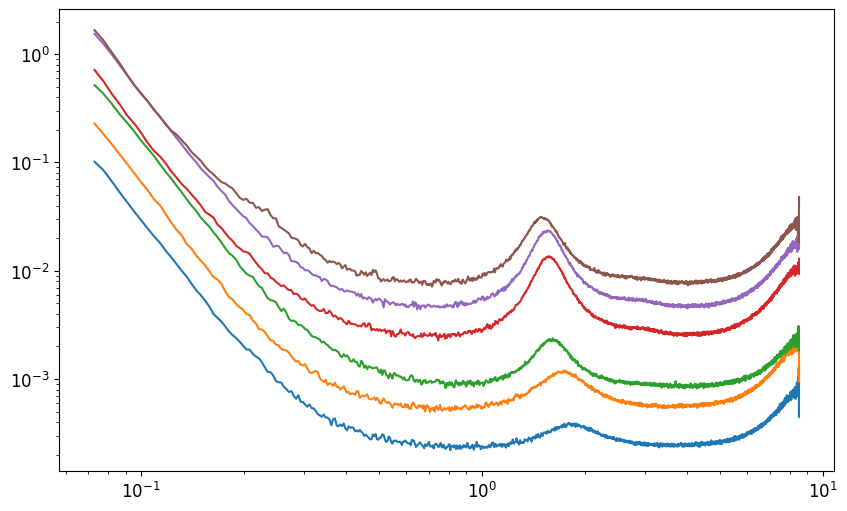

In [275]:
k = 2
path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00208_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I / k**3)
df = pd.DataFrame({'q_0':q, 'I_0': I / k**3})
df.to_csv(r'E:\OH_PDMS\data\N0_melt.txt', sep=str('\t'), index=False)


path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00236_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I  / k**2)
df = pd.DataFrame({'q_20':q, 'I_20':I  / k**2})
df.to_csv(r'E:\OH_PDMS\data\N20_melt.txt', sep=str('\t'), index=False)

path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00226_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I  / k**1)
df = pd.DataFrame({'q_50':q, 'I_50':I  / k**1})
df.to_csv(r'E:\OH_PDMS\data\N50_melt.txt', sep=str('\t'), index=False)

path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00220_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I  / k**0)
df = pd.DataFrame({'q_80':q, 'I_80':I  / k**0})
df.to_csv(r'E:\OH_PDMS\data\N80_melt.txt', sep=str('\t'), index=False)

path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00215_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I  / k**-1)
df = pd.DataFrame({'q_90':q, 'I_90':I  / k**-1})
df.to_csv(r'E:\OH_PDMS\data\N90_melt.txt', sep=str('\t'), index=False)

path = r'\\Synology\Data\2024\sc5600\id02\20240906\PROCESSED_DATA\Ivanov\Ivanov_20240906-115451\Ivanov_eiger2_00201_00_norm.h5'

Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
plt.loglog(q, I  / k**-2)
df = pd.DataFrame({'q_100':q, 'I_100':I  / k**-2})
df.to_csv(r'E:\OH_PDMS\data\N100_melt.txt', sep=str('\t'), index=False)

# **Figures**

In [200]:
def norm_saxs(res):
    q = res[0]
    I = res[1]
    return q, I / np.mean(I[(q>0.1)*(q<0.2)])

In [201]:
from scipy.special import voigt_profile

def gaussian(x, A, x0, sigma, C):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + C

def lorentzian(x, A, x0, gamma, C):
    return A * (gamma**2 / ((x - x0)**2 + gamma**2)) + C

def voigt(x, A, x0, sigma, gamma, C):
    res = voigt_profile(x-x0, sigma, gamma)
    res /= max(res)
    return A * res + C

def model_2peaks(x, x1, A1, sigma1, gamma1, x2, A2, sigma2, gamma2, C):
    return voigt(x, A1, x1, sigma1, gamma1, 0) + voigt(x, A2, x2, sigma2, gamma2, 0) + C

In [202]:
def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    return [lin_interp(x, y, zero_crossings_i[0], half),
            lin_interp(x, y, zero_crossings_i[1], half)]

def lin_interp(x, y, i, half):
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

## Hexagonal

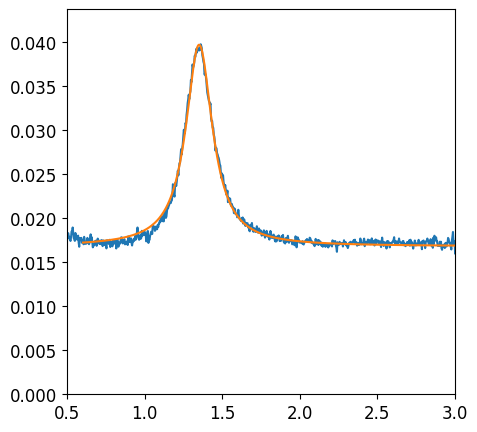

In [203]:

plt.figure(figsize=(5, 5))
q, I = Exp_heat_2.average_1d([55, 56, 57])
plt.plot(q, I)
plt.xlim(0.5, 3)
l, r = 0.6, 3
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
p, cov = curve_fit(lorentzian, x, y)

plt.plot(x, lorentzian(x, *p))
plt.ylim(0, 1.1 * max(y))

gamma_amorph = 0.10391029

In [120]:
def model(x, x1, A1, sigma1, gamma1, x2, A2, C):
    return voigt(x, A1, x1, sigma1, gamma1, 0) + lorentzian(x, A2, x2, gamma_amorph, 0) + C

(1.2, 1.6)

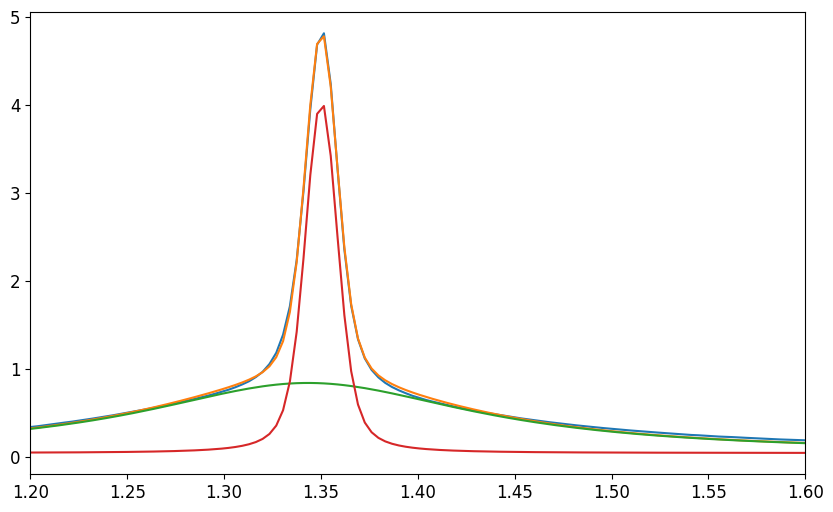

In [204]:
q, I = Exp_aft_5hrs.average_1d([0,1,2])

l, r = 0.6, 1.7
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]

plt.plot(x, y)

x2 = 1.34
A2 = 0.7
C = 0.04

x1 = 1.35
A1 = 4
sigma1 = 0.001
gamma1 = 0.009

# plt.plot(x, lorentzian(x, A2, x2, gamma_amorph, C))
# plt.plot(x, voigt(x, A1, x1, sigma1, gamma1, 0))

p0 = [x1, A1, sigma1, gamma1, x2, A2, C]
p, cov = curve_fit(model, x, y, maxfev = 5000, 
                   bounds=((1.3, 0, 0, 0, 1.3, 0, 0),(1.4, np.inf, np.inf, np.inf, 1.4, np.inf, np.inf)),
                  )

plt.plot(x, model(x, *p))
plt.plot(x, lorentzian(x, p[5], p[4], gamma_amorph, p[-1]))
plt.plot(x, voigt(x, p[1], p[0], p[2], p[3], p[-1]))
# plt.plot(x, voigt(x, A1, x1, sigma1, gamma1, 0))
plt.xlim(1.2, 1.6)

0.02049840449014373


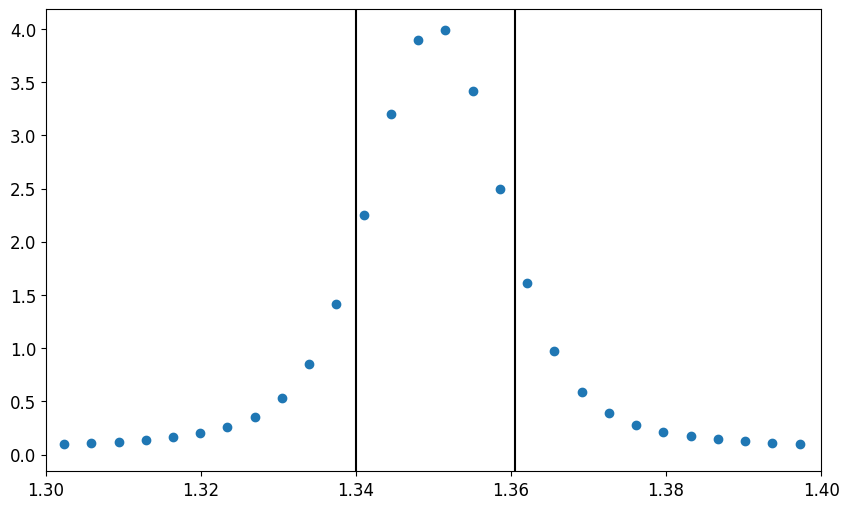

In [197]:
plt.scatter(x, voigt(x, p[1], p[0], p[2], p[3], p[-1]))
left, right = half_max_x(x, voigt(x, p[1], p[0], p[2], p[3], 0))
plt.axvline(x=right, color='black')
plt.axvline(x=left, color='black')
plt.xlim(1.3, 1.4)
0.9 * pi * 2 / (right-left)
print(right-left)

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_14500\796137824.py:9: OptimizeWarning:

Covariance of the parameters could not be estimated



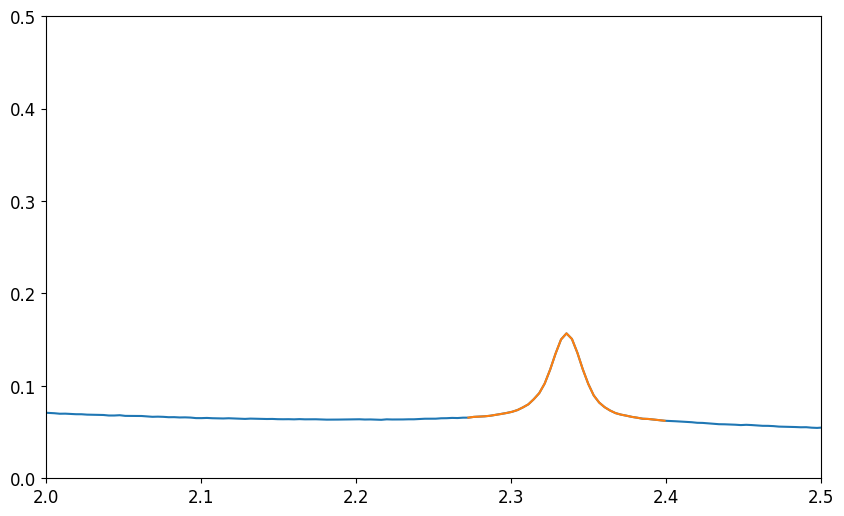

In [185]:
plt.plot(q, I)
plt.xlim(2, 2.5)
plt.ylim(0, 0.5)

l, r = 2.27, 2.4
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]

plt.plot(x, y)
p, cov = curve_fit(linear, [x[0], x[-1]], [y[0], y[-1]])
y -= linear(x, *p)

np.float64(231.41261778449712)

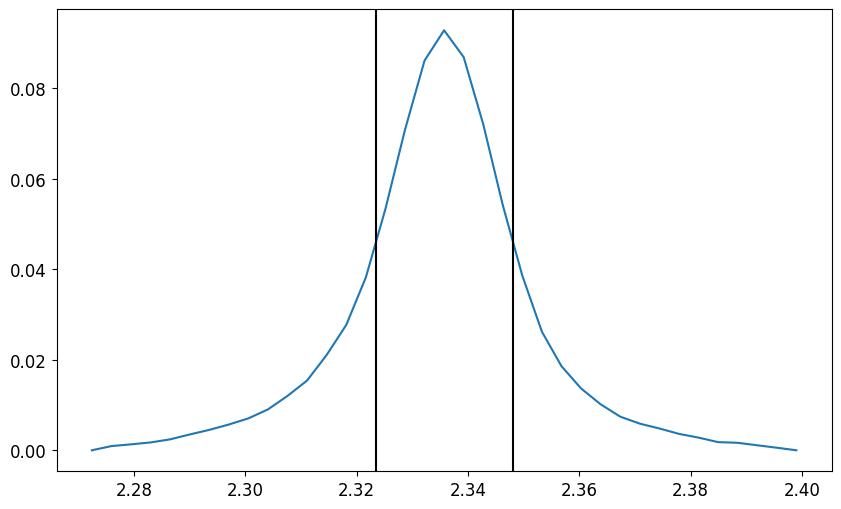

In [189]:
plt.plot(x, y)
left, right = half_max_x(x,y)
plt.axvline(x=right, color='black')
plt.axvline(x=left, color='black')

0.9 * pi * 2 / (right-left)

[]

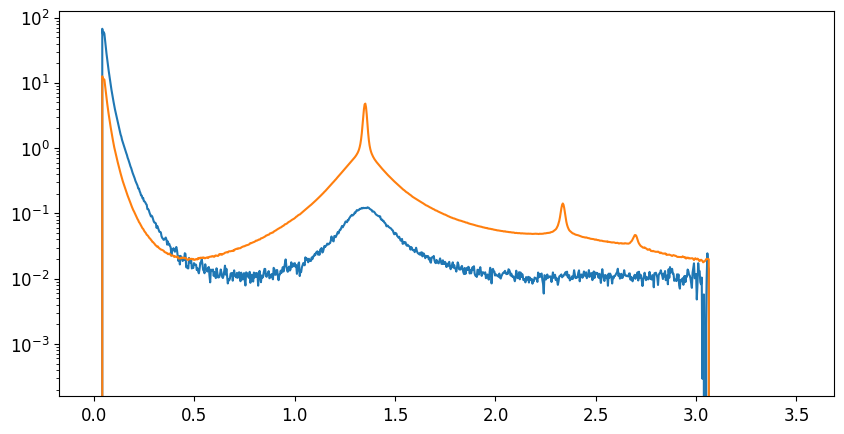

In [73]:

plt.figure(figsize=(10, 5))
q, I = Exp_heat_2.average_1d([55, 56, 57])
plt.plot(q, (I - 0.015) * 5)

q, I = Exp_aft_5hrs.average_1d([0,1,2])
plt.plot(q, I - 0.015)

# plt.xlim(0.5, 3)
plt.semilogy()

# l, r = 0.5, 2.2
# x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
# plt.scatter([x[0], x[-1]], [y[0], y[-1]], marker='x', color='black', zorder=10)

# p, cov = curve_fit(linear, [x[0], x[-1]], [y[0], y[-1]])
# plt.plot(q, linear(q, *p))

# y -= linear(x, *p)

In [43]:
model_2peaks

<function __main__.model_2peaks(x, x1, A1, sigma1, gamma1, x2, A2, sigma2, gamma2, C)>

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_14500\3122123346.py:11: RuntimeWarning:

invalid value encountered in divide



array([ 2.91890086e+00,  1.20298972e+03,  6.42324542e+02,  7.39687544e+01,
        1.35007135e+00,  4.43465911e+00,  6.65808404e-07,  1.36103875e-02,
       -1.20290454e+03])

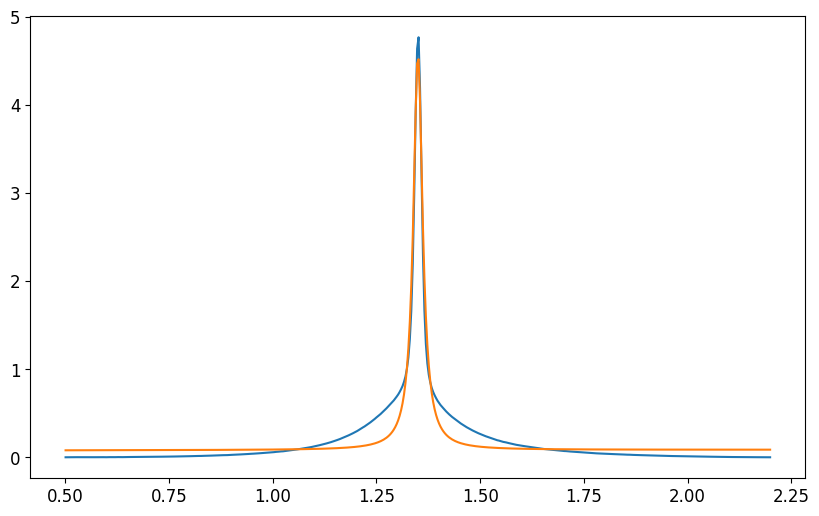

In [47]:
plt.plot(x, y)

p, cov = curve_fit(model_2peaks, x, y, p0=[1.35, 1, 1, 0.1, 1.3, 5, 0.01, 0.01, 0])

plt.plot(x, model_2peaks(x, *p))
p

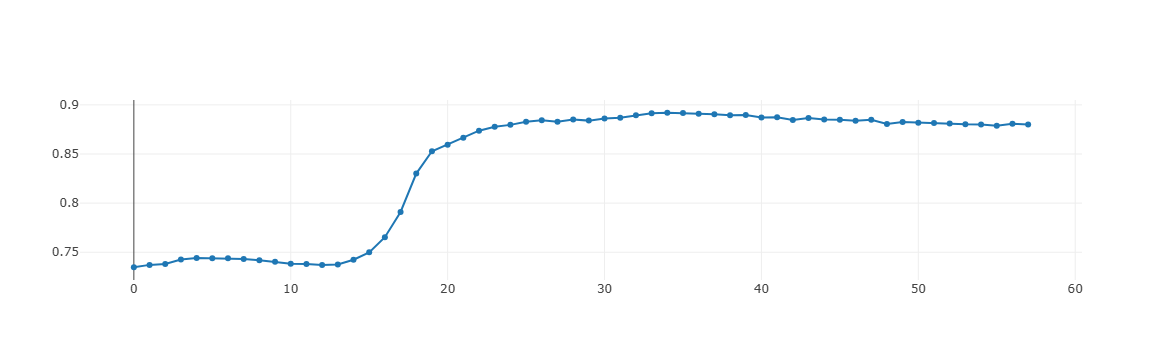

In [245]:
plot_curves(np.arange(58), Tr_heat_2,
            labels=[ 'heat2'])

[]

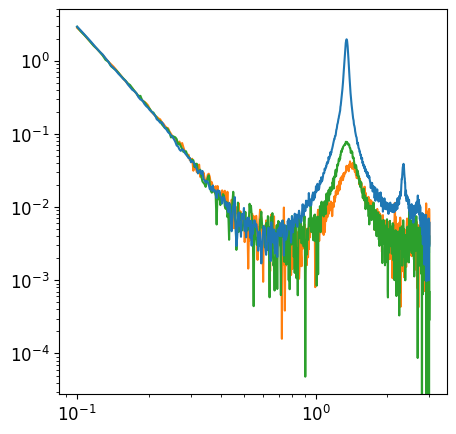

In [229]:
l = 0.1
r = 3

plt.figure(figsize=(5,5))
i = 0
q, I = norm_saxs(Exp_heat_2.get_1d_SAXS(i))
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
y -= 0.9 * np.mean(y[(x>0.5)*(x<0.6)])
plt.plot(x, y, zorder=10)

i = 29
q, I = norm_saxs(Exp_heat_2.get_1d_SAXS(i))
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
y -= 0.9 * np.mean(y[(x>0.5)*(x<0.6)])
plt.plot(x, y)

i = 57
q, I = norm_saxs(Exp_heat_2.get_1d_SAXS(i))
x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
y -= 0.9 * np.mean(y[(x>0.5)*(x<0.6)])

plt.plot(x, y)

plt.semilogy()
plt.semilogx()



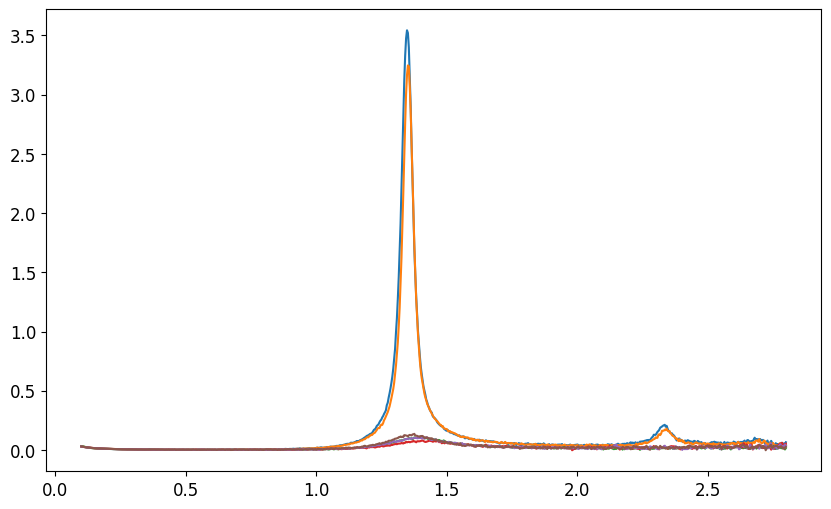

In [240]:
Area = []
for i in range(58):
    q, I = norm_saxs(Exp_heat_2.get_1d_SAXS(i))
    l = 0.1
    r = 2.8
    x, y = q[(q>l)*(q<r)], I[(q>l)*(q<r)]
    y -= 0.9 * np.mean(y[(x>0.5)*(x<0.6)])

    Area.append(np.trapezoid(y[(x>1)*(x<2.8)] * x[(x>1)*(x<2.8)]  ** 2, x=x[(x>1)*(x<2.8)] ))

    if i % 10 == 0:
        plt.plot(x, y * x ** 2)

Found 58 EDF files in SAXS


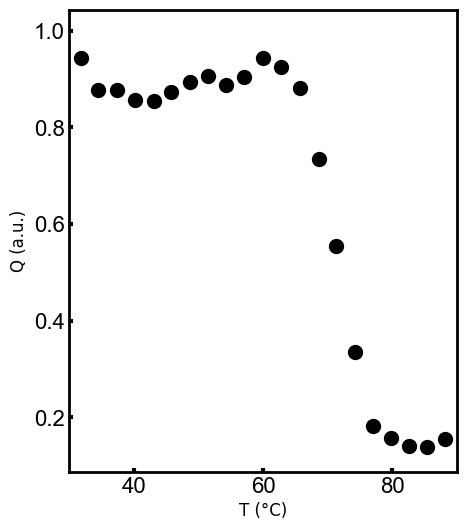

In [249]:
fig, ax = plt.subplots(figsize=(5, 6))

Area = np.array(Area)
plt.scatter(Exp_heat_2.get_T_profile()[:28], Area[:28] / max(Area) , color='black', s=100)
plt.xlabel('T (°C)')
plt.ylabel('Q (a.u.)')

plt.xlim(30, 90)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

In [252]:
print(*Exp_heat_2.get_T_profile()[:28], sep='\n')


Found 58 EDF files in SAXS
25.3
28.5
31.8
34.5
37.3
40.2
43.1
45.8
48.7
51.4
54.3
57.1
59.9
62.7
65.7
68.6
71.3
74.2
77.0
79.8
82.6
85.4
88.2
91.2
94.0
96.8
99.6
100.1


In [255]:
print(*(Area[:28] / max(Area)), sep='\n')


1.0
0.9641478154171734
0.9433911121060196
0.8778540641273216
0.8765087871701055
0.8570654054816165
0.8551129978249197
0.8727637205318083
0.8937115151725897
0.906354142483033
0.8866556417922654
0.9037770219783804
0.9432570438849269
0.9244011500453814
0.8802836861993589
0.7335070035626758
0.5550516932683154
0.33483003584895604
0.1817469078322655
0.1565514975150523
0.14096799213692732
0.13917492224290226
0.15534798745013592
0.1575295276562203
0.14321548544102555
0.13696753351807647
0.1313552945603543
0.14061492501589917


In [76]:
(2.335 / 1.350) ** 2

2.991618655692729

In [75]:
(2.697 / 1.350) ** 2


3.9911160493827156